# Image recognition with our own photos

This notebook presents our second task, which is to use our own convolutional neural network and another pre-trained model to perform image recognition on a dataset of our own photos. The goal is to achieve the highest possible accuracy on the validation set by experimenting with different architectures. We have gathered images of chairs and pens, which are the two classes we want to classify. By picking two quite distinct classes we are hoping to get a good accuracy even with a simple model. We will start by loading and preprocessing the images, then we will build and train our own convolutional neural network, and finally we will use a pre-trained model for feature extraction and classification. Let's get started!

In [17]:
import warnings
# Suppress NumPy 2.4 deprecation warning from Keras pickle loading
warnings.filterwarnings("ignore", message=".*align should be passed as Python or NumPy boolean.*")

In [18]:
# imports
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, models
from keras.src.utils import image_dataset_from_directory
from keras.src.applications.vgg16 import VGG16

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

tensorflow


## Loading and processing our own photos

For this task, we have collected a dataset of our own photos, which consists of images of chairs and pens. The dataset is organized into two folders: `chairs` and `pens`, each containing the respective images. We will load these images using the `image_dataset_from_directory` function from Keras, which allows us to easily create a dataset from a directory structure.

The Images are already cropped and downscaled so they dont take too much disk space, but will still set parameters to confirm all images have the same scale. `image_size=(256, 256)` will resize all images to 256x256 pixels, and `label_mode='binary'` will assign binary labels to the images (0 for chairs and 1 for pens). We will also set `shuffle=True` to ensure that the data is shuffled during loading, and `seed=42` for reproducibility. After loading the dataset, we will convert it into numpy arrays for further processing.

In [19]:
# Load full dataset from both folders
dataset = image_dataset_from_directory(
    'Resources',
    image_size=(256, 256),
    batch_size=None,        # load all at once as individual samples
    label_mode='binary',    # binary since we have 2 classes (chairs/pens)
    shuffle=True,
    seed=42
)

# Convert to numpy arrays
xy = [(img, label) for img, label in dataset]
x = np.array([item[0].numpy() for item in xy])
y = np.array([item[1].numpy() for item in xy])

print("Total images:", x.shape)
print("Total labels:", y.shape)
print("Class names:", dataset.class_names)

# Scale pixel values to [0, 1]
x = x / 255.0

# Split into train (70%), validation (15%), test (15%)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

# Flatten labels from (n, 1) to (n,)
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

print("y_train shape:", y_train.shape)
print("y_train unique values:", np.unique(y_train))

Found 174 files belonging to 2 classes.
Total images: (174, 256, 256, 3)
Total labels: (174, 1)
Class names: ['Chairs', 'Pens']
Training set: (121, 256, 256, 3)
Validation set: (26, 256, 256, 3)
Test set: (27, 256, 256, 3)
y_train shape: (121,)
y_train unique values: [0. 1.]


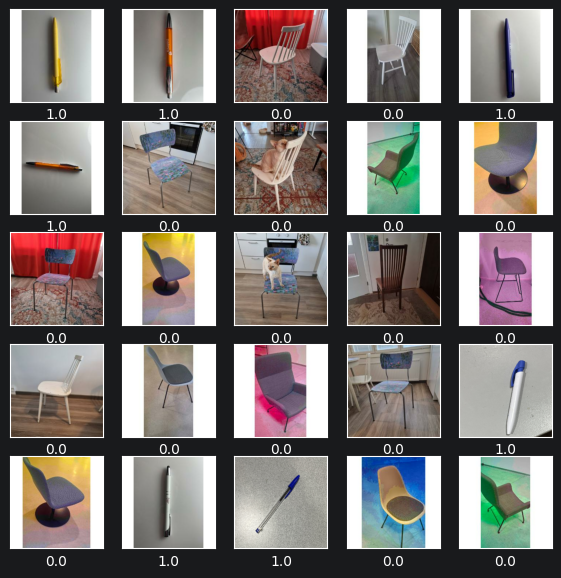

In [20]:
# use plt to visualize some of the images
plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(y_train[i])
plt.show()

Finally for the preparation step we will set some parameters for the training.

In [21]:
# Hyperparameters
batch_size   = 256       # Number of images the model sees before updating its weights
epochs       = 100       # How many times the model will go through the entire dataset

## Building and training our own convolutional neural network

In [22]:
model_cnn = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    15,745,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,545 (60.14 MB)

 Trainable params: 15,764,545 (60.14 MB)

 Non-trainable params: 0 (0.00 B)

### Training the CNN model

During the training we are utilizing the EarlyStopping callback to monitor the validation loss. If the validation loss does not improve for 10 consecutive epochs, the training will stop and the best weights will be restored. We are also computing class weights to address any potential class imbalance in the dataset, which can help the model to learn more effectively from both classes (chairs and pens) and improve overall performance.

In [23]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.7202380952380952), 1: np.float64(1.635135135135135)}


In [24]:
history = model_cnn.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val),
    class_weight=class_weight_dict,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)

In [35]:
# Helper functions
def plot_training_history(history, title='Training History'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(epochs, acc, 'r--', linewidth=2, label='Training accuracy')
    ax1.plot(epochs, val_acc, 'b', linewidth=2, label='Validation accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    ax2.plot(epochs, loss, 'r--', linewidth=2, label='Training loss')
    ax2.plot(epochs, val_loss, 'b', linewidth=2, label='Validation loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, features, labels, title='Confusion Matrix'):
    pred_labels = (model.predict(features) > 0.5).astype(int).flatten()
    cm = confusion_matrix(labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.class_names)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()


def plot_sample_predictions(model, features, images, labels, title='Sample Predictions'):
    predictions = model.predict(features)

    fig, axes = plt.subplots(2, 5, figsize=(10, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            pred = predictions[i][0]
            true_label = dataset.class_names[int(labels[i])]
            pred_label = dataset.class_names[int(pred > 0.5)]
            confidence = pred if int(pred > 0.5) == 1 else (1 - pred)
            ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

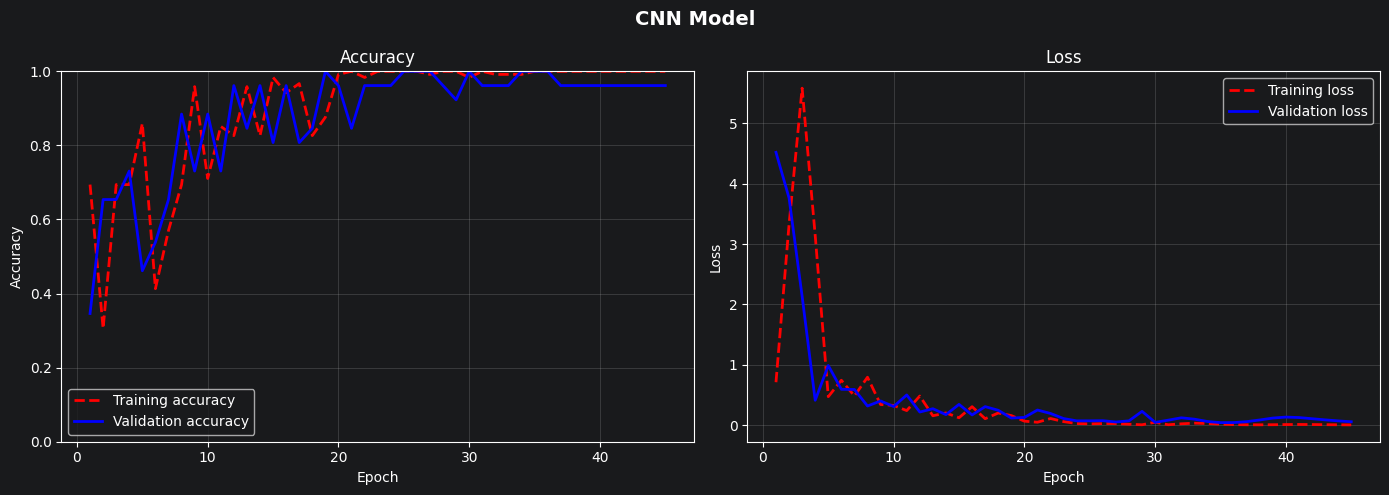

In [36]:
plot_training_history(history, title='CNN Model')

In [37]:
score = model_cnn.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.018555866554379463
Test accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


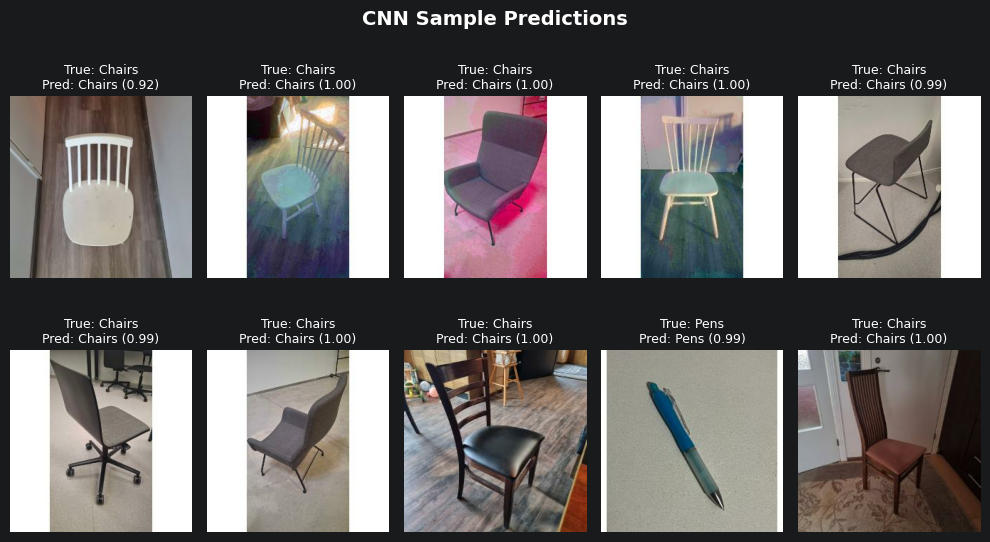

In [38]:
plot_sample_predictions(model_cnn, x_test, x_test, y_test, title='CNN Sample Predictions')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


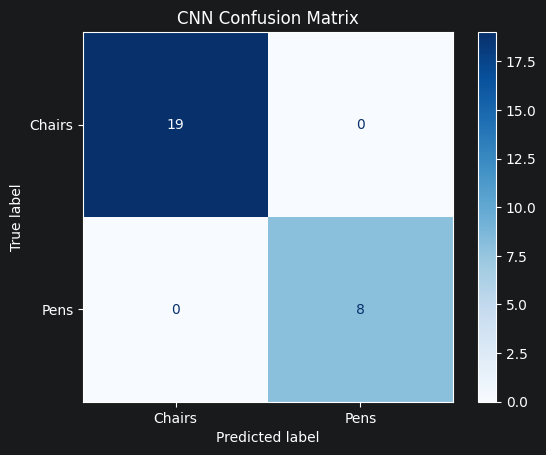

In [40]:
plot_confusion_matrix(model_cnn, x_test, y_test, title='CNN Confusion Matrix')